# Pedestrian Count Analysis - La Trobe Street vs Lonsdale Street

Author - Isaac McKissack

Source - https://discover.data.vic.gov.au/dataset/pedestrian-counting-system-counts-per-hour

In [1]:
# Importing Core Packages for use in Data Visualisation

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
from scipy.signal import find_peaks
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
# Importing Packages for Dataset Import

import urllib.request
import yaml
from pathlib import Path

# Load project configuration

config_path = Path("../config.yaml")
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

raw_dir = Path("../") / config["paths"]["raw_dir"]
raw_dir.mkdir(parents=True, exist_ok=True)

def download_url(url, dest_name):
    dest_path = raw_dir / dest_name
    if dest_path.exists():
        print(f"{dest_name} already exists. Skipping.")
        return
    print(f"Downloading {dest_name}...")
    urllib.request.urlretrieve(url, dest_path)
    print(f"Saved to {dest_path}")

# Download Dataset to local raw for processing

download_url(config["data_sources"]["pedestrian_counting_system"], "pedestrian_counting_system.geojson")



pedestrian_counting_system.geojson already exists. Skipping.


In [3]:
# Importing pedestrian data

pedestrian_data_raw = gpd.read_file("../data/raw/pedestrian_counting_system.geojson")

c:\Users\incar\Documents\University\Victoria-Urban-Planning\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 61320260807 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


In [4]:
# Scanning for nulls

pedestrian_data_raw.isna().sum()

# Null Locations due to quirk of dataset - not relevant

id                       0
location_id              0
sensing_date             0
hourday                  0
direction_1              0
direction_2              0
pedestriancount          0
sensor_name          25363
location           1614785
geometry             25363
dtype: int64

In [5]:
# Isolating for sensor_name with valid rows

pedestrian_data_clean = pedestrian_data_raw[pedestrian_data_raw['sensor_name'].notna()]

# Split dates into year and month for grouping analysis

pedestrian_data_clean['year_month'] = pd.to_datetime(pedestrian_data_clean['sensing_date']).dt.strftime('%Y-%m')

# Sort dates chronlogically

pedestrian_data_clean = pedestrian_data_clean.sort_values(by=['year_month'])

In [6]:
# Per a QGIS analysis of sensor locations, separate into two datasets - Lonsdale St and La Trobe St
# Lonsdale St - sensors 108, 47, 3 in broader buffer area, not on Lonsdale St

lonsdale_sensors = [133, 56, 52, 30, 108, 47, 3]

pedestrian_lonsdale = pedestrian_data_clean[pedestrian_data_clean['location_id'].isin(lonsdale_sensors)]

In [7]:
# La Trobe St - sensors 107, 108, 59, 61, 66, 3 in broader buffer area, not on La Trobe St

latrobe_sensors = [164, 167, 132, 109, 62, 187, 107, 108, 59, 61, 66, 3]

# Sensor 181 is located on La Trobe St but was introduced part way through the dataset, and so is not included in the analysis to avoid skewing results

pedestrian_latrobe = pedestrian_data_clean[pedestrian_data_clean['location_id'].isin(latrobe_sensors)]

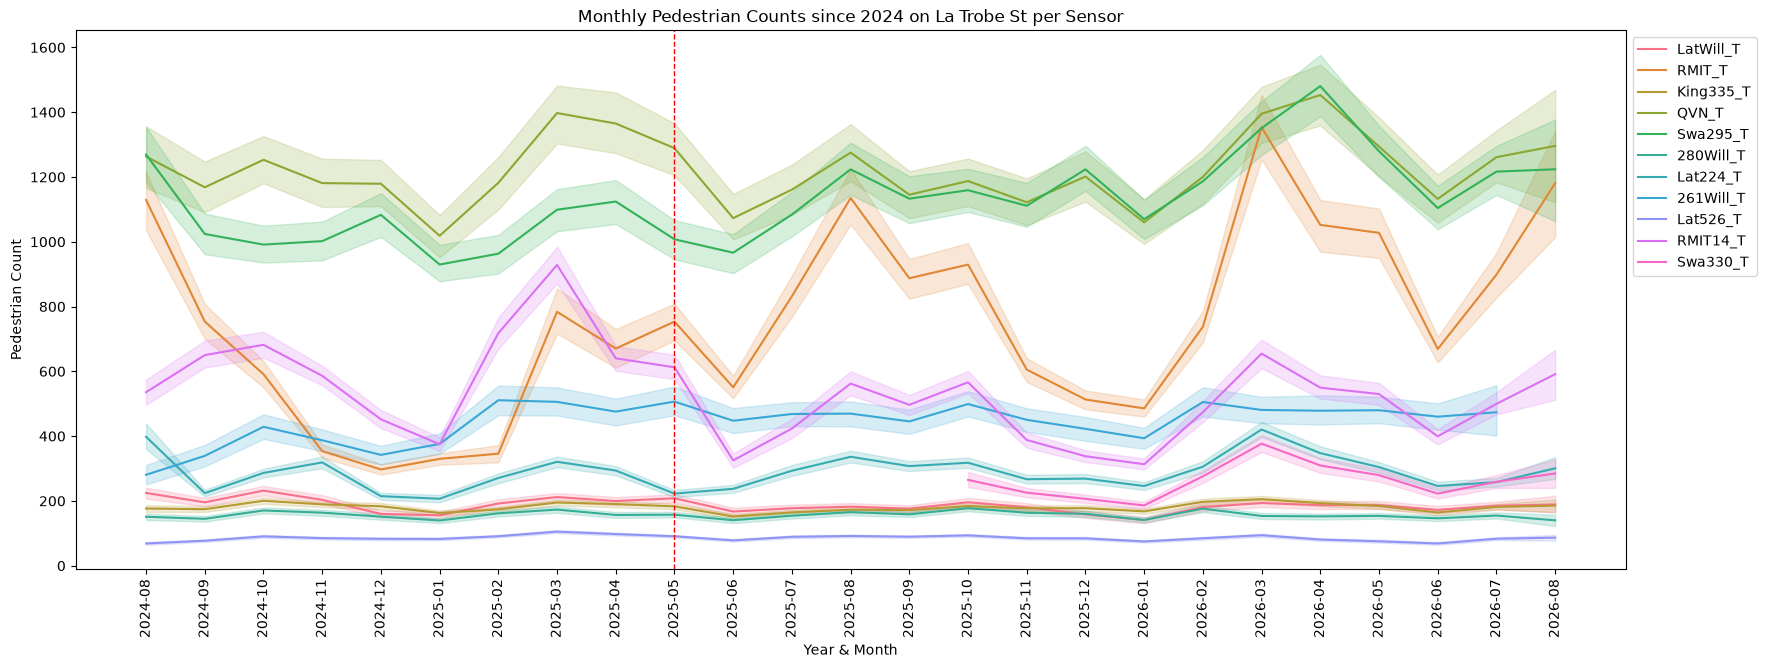

In [8]:
# Plot La Trobe St buffer sensors, allowing us to see any gaps that can explain overall trends

fig, ax = plt.subplots(figsize = (20, 7))
sns.lineplot(data = pedestrian_latrobe, x = "year_month", y = "pedestriancount", ax = ax, hue = "sensor_name")
plt.title("Monthly Pedestrian Counts since 2024 on La Trobe St per Sensor")
plt.xlabel("Year & Month")
plt.xticks(rotation = 90)
plt.ylabel("Pedestrian Count")
ax.legend(bbox_to_anchor=(1, 1))
ax.axvline(x='2025-05', color='red', linestyle='--', linewidth=1)

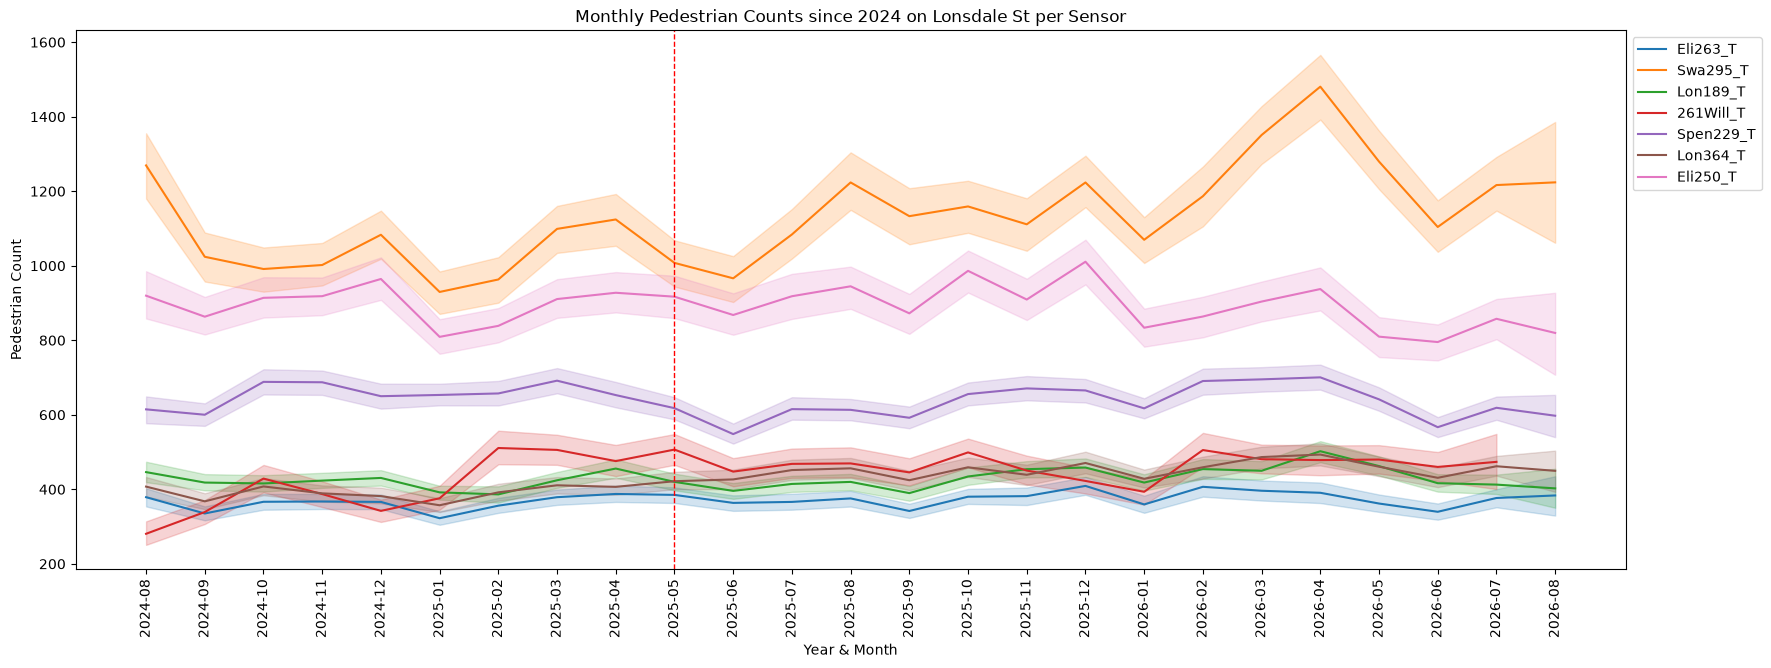

In [9]:
# Plot Lonsdale St buffer sensors, allowing us to see any gaps that can explain overall trends

fig, ax = plt.subplots(figsize = (20, 7))
sns.lineplot(data = pedestrian_lonsdale, x = "year_month", y = "pedestriancount", ax = ax, hue = "sensor_name")
plt.title("Monthly Pedestrian Counts since 2024 on Lonsdale St per Sensor")
plt.xlabel("Year & Month")
plt.xticks(rotation = 90)
plt.ylabel("Pedestrian Count")
ax.legend(bbox_to_anchor=(1, 1))
ax.axvline(x='2025-05', color='red', linestyle='--', linewidth=1)

In [10]:
# Sum monthly counts within each street, and drop the last month as it is assumed to be incomplete

latrobe_summed = pedestrian_latrobe.groupby("year_month", as_index = False, sort = False)["pedestriancount"].sum()
latrobe_summed.drop(latrobe_summed.tail(1).index, inplace = True)

lonsdale_summed = pedestrian_lonsdale.groupby("year_month", as_index = False, sort = False)["pedestriancount"].sum()
lonsdale_summed.drop(lonsdale_summed.tail(1).index, inplace = True)

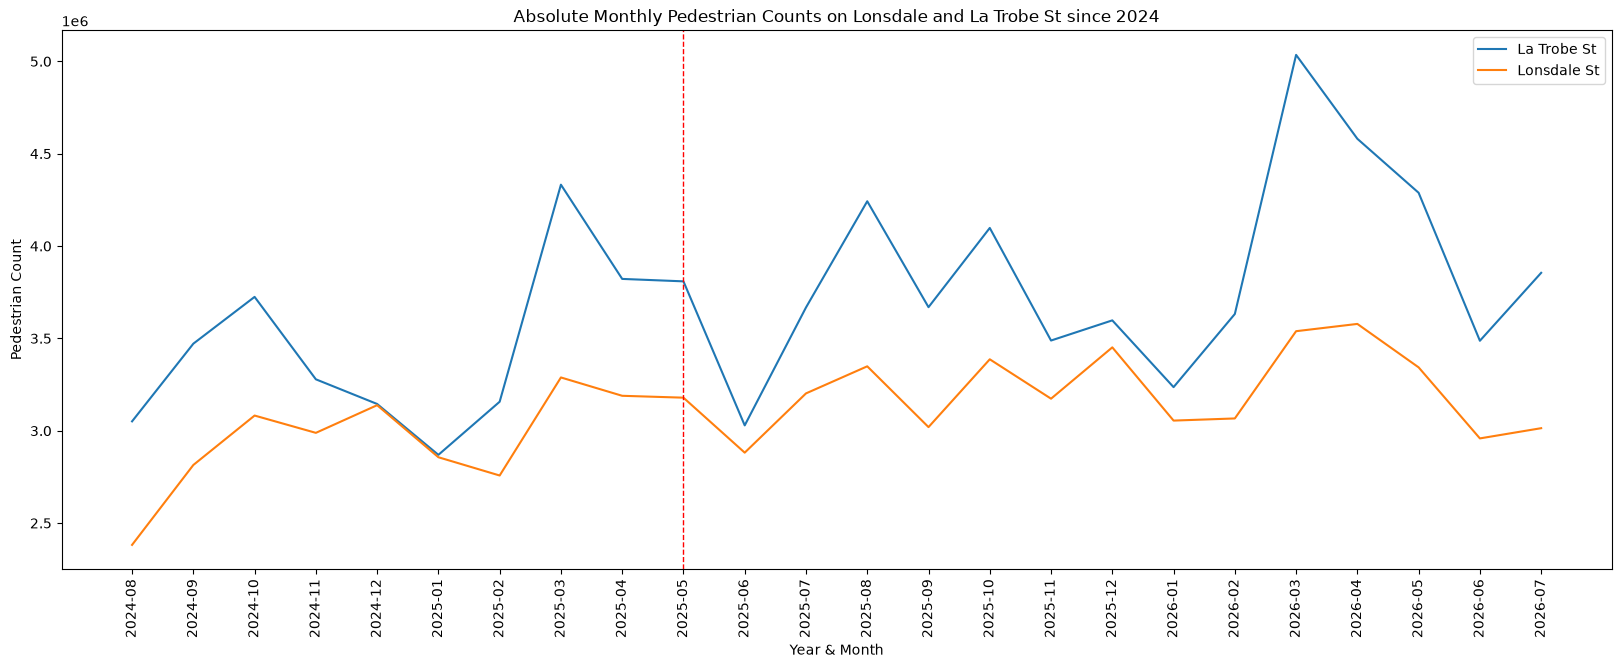

In [11]:
# Chart monthly pedestrian counts across La Trobe St and Lonsdale St, using summed data

fig, ax = plt.subplots(figsize = (20, 7))

sns.lineplot(data = latrobe_summed, x = "year_month", y = "pedestriancount", ax = ax, label = "La Trobe St")
sns.lineplot(data = lonsdale_summed, x = "year_month", y = "pedestriancount", ax = ax, label = "Lonsdale St")

plt.title("Absolute Monthly Pedestrian Counts on Lonsdale and La Trobe St since 2024")
plt.xlabel("Year & Month")
plt.xticks(rotation = 90)
plt.ylabel("Pedestrian Count")
ax.legend()
ax.axvline(x='2025-05', color='red', linestyle='--', linewidth=1)

plt.show()

In [12]:
# Create a new dataframe that calculates the difference in pedestrian counts between La Trobe St and Lonsdale St for each month

pedestrian_summed_difference = {"year_month": latrobe_summed["year_month"], "pedestriancount": (latrobe_summed["pedestriancount"] - lonsdale_summed["pedestriancount"])}

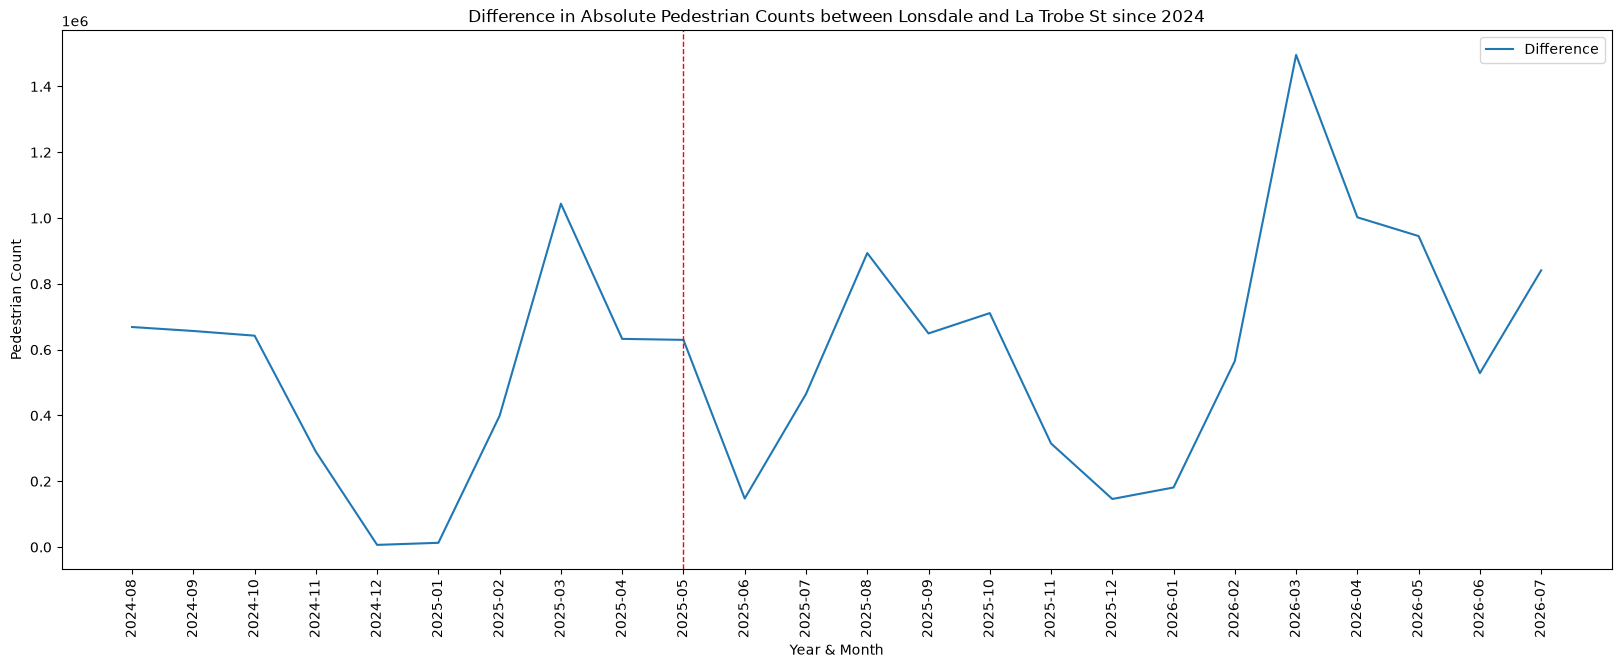

In [13]:
# Graph the difference in pedestrian counts between La Trobe St and Lonsdale St for each month

fig, ax = plt.subplots(figsize = (20, 7))

sns.lineplot(data = pedestrian_summed_difference, x = "year_month", y = "pedestriancount", ax = ax, label = "Difference")

plt.title("Difference in Absolute Pedestrian Counts between Lonsdale and La Trobe St since 2024")
plt.xlabel("Year & Month")
plt.xticks(rotation = 90)
plt.ylabel("Pedestrian Count")
ax.legend()
ax.axvline(x='2025-05', color='red', linestyle='--', linewidth=1)

plt.show()

In [14]:
# Divide the summed pedestrian counts by the number of sensors in each street to get an average per sensor, allowing for a more accurate comparison between streets with different numbers of sensors

latrobe_summed["pedestriancount"] = latrobe_summed["pedestriancount"] / len(latrobe_sensors)
lonsdale_summed["pedestriancount"] = lonsdale_summed["pedestriancount"] / len(lonsdale_sensors)

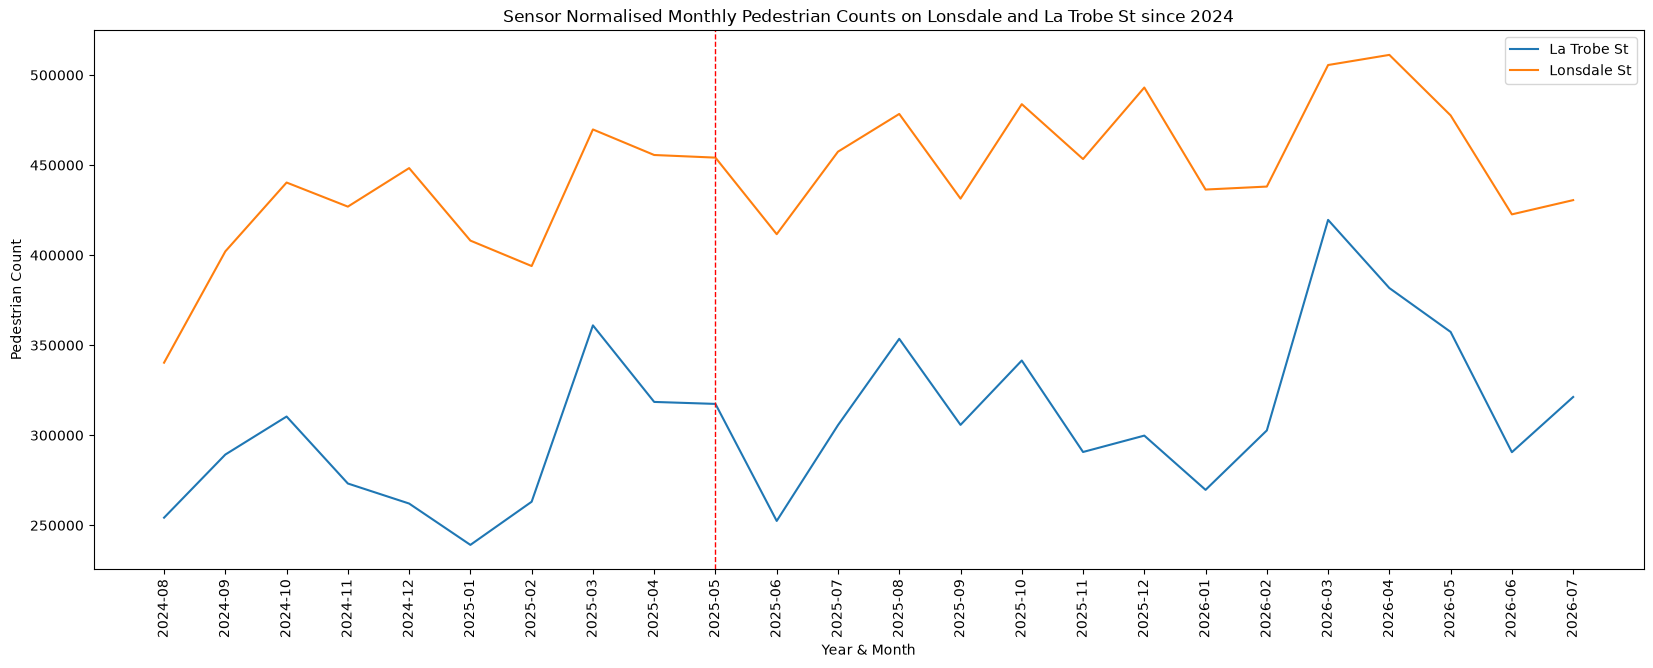

In [15]:
# Graph the average pedestrian counts per sensor between La Trobe St and Lonsdale St for each month

fig, ax = plt.subplots(figsize = (20, 7))

sns.lineplot(data = latrobe_summed, x = "year_month", y = "pedestriancount", ax = ax, label = "La Trobe St")
sns.lineplot(data = lonsdale_summed, x = "year_month", y = "pedestriancount", ax = ax, label = "Lonsdale St")

plt.title("Sensor Normalised Monthly Pedestrian Counts on Lonsdale and La Trobe St since 2024")
plt.xlabel("Year & Month")
plt.xticks(rotation = 90)
plt.ylabel("Pedestrian Count")
ax.legend()
ax.axvline(x='2025-05', color='red', linestyle='--', linewidth=1)

plt.show()

In [16]:
# Create a new dataframe that calculates the difference in normalised pedestrian counts between La Trobe St and Lonsdale St for each month

pedestrian_normalised_summed_difference = {"year_month": latrobe_summed["year_month"], "pedestriancount": (lonsdale_summed["pedestriancount"] - latrobe_summed["pedestriancount"])}

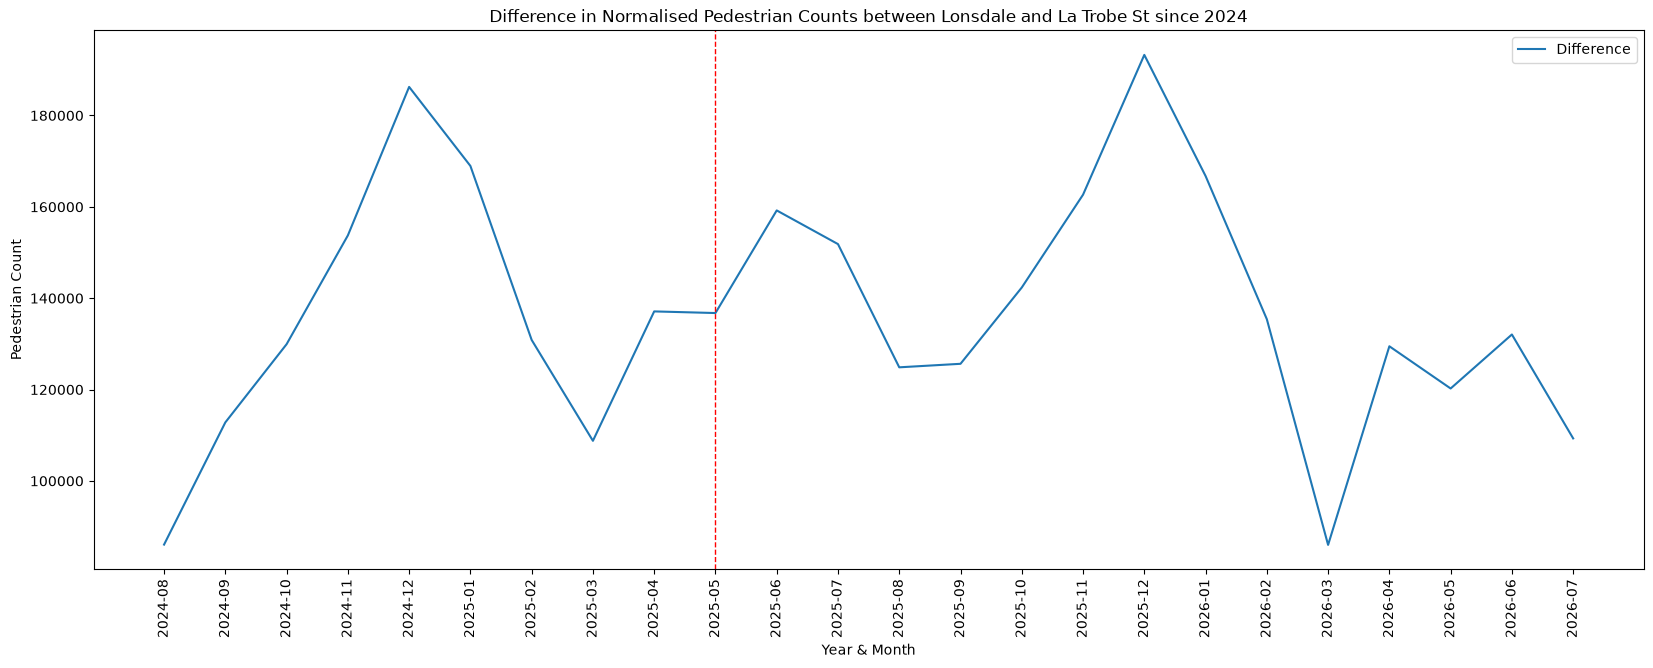

In [17]:
# Graph the difference in pedestrian counts between La Trobe St and Lonsdale St for each month

fig, ax = plt.subplots(figsize = (20, 7))

sns.lineplot(data = pedestrian_normalised_summed_difference, x = "year_month", y = "pedestriancount", ax = ax, label = "Difference")

plt.title("Difference in Normalised Pedestrian Counts between Lonsdale and La Trobe St since 2024")
plt.xlabel("Year & Month")
plt.xticks(rotation = 90)
plt.ylabel("Pedestrian Count")
ax.legend()
ax.axvline(x='2025-05', color='red', linestyle='--', linewidth=1)

plt.show()